# Project 1: Fast Food Marketing Campaign A/B Test

## Scenario

A fast-food chain plans to add a new item to its menu but is undecided between **three possible marketing campaigns**. To determine which promotion has the greatest effect on sales, the new item is introduced at locations in several randomly selected markets. A different promotion is used at each location, and the weekly sales of the new item are recorded for the first four weeks.

## Goal

Evaluate A/B testing results and decide which marketing strategy works the best.

## Dataset Columns

| Column | Description |
|--------|-------------|
| `MarketID` | Unique identifier for market |
| `MarketSize` | Size of market area by sales |
| `LocationID` | Unique identifier for store location |
| `AgeOfStore` | Age of store in years |
| `Promotion` | One of three promotions that were tested |
| `week` | One of four weeks when the promotions were run |
| `SalesInThousands` | Sales amount for a specific LocationID, Promotion, and week |

## Approach

**Type of Analysis:** CDA (Confirmatory Data Analysis) — we have a specific question to answer.

**Sub-Questions:**
1. What does the sales distribution look like per promotion?
2. Are the differences statistically significant, and which promotions differ?

## Setup

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Config
ALPHA = 0.05
DATA_PATH = "WA_Marketing-Campaign.csv"

## Data Loading & Quick Validation

We load the dataset and verify its structure: shape, data types, and missing values.

In [82]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
df.head()

Shape: (548, 7)

Data Types:
 MarketID              int64
MarketSize              str
LocationID            int64
AgeOfStore            int64
Promotion             int64
week                  int64
SalesInThousands    float64
dtype: object

Missing Values:
 MarketID            0
MarketSize          0
LocationID          0
AgeOfStore          0
Promotion           0
week                0
SalesInThousands    0
dtype: int64


,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


The dataset has **548 rows** and **7 columns** with **no missing values**. Each row represents one store's sales in one week under one promotion.

In [83]:
df.groupby('Promotion')['SalesInThousands'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Promotion,,,,,,,,
1,172.0,58.10,16.55,30.81,46.35,55.39,63.62,99.65
2,188.0,47.33,15.11,17.34,38.17,45.39,51.74,88.64
3,188.0,55.36,16.77,22.18,44.20,51.16,61.73,96.48


At a glance, Promotion 1 has the highest mean sales (~58k), while Promotion 2 has the lowest (~47k). Let's visualize this further.

## Q1: What does the sales distribution look like per promotion?

We aggregate sales per store (averaging across 4 weeks) and visualize the distribution for each promotion using a boxplot with individual data points.

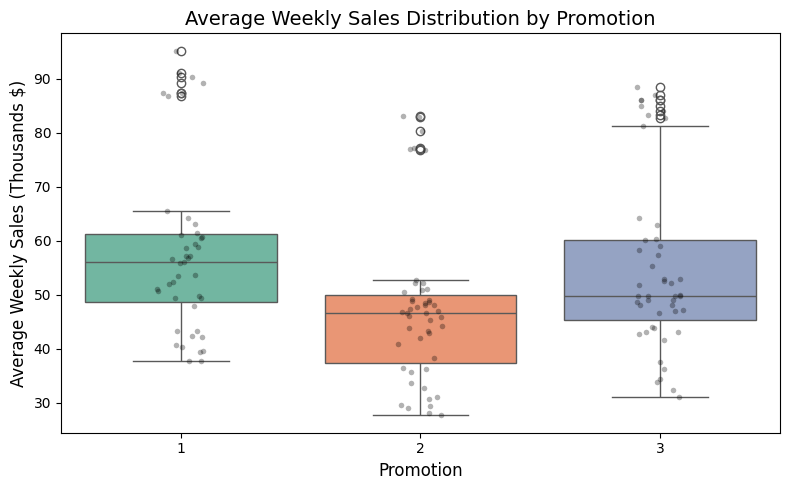

In [84]:
store_avg = df.groupby(['LocationID', 'Promotion'])['SalesInThousands'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=store_avg, x='Promotion', y='SalesInThousands', hue='Promotion', palette='Set2', legend=False, ax=ax)
sns.stripplot(data=store_avg, x='Promotion', y='SalesInThousands', color='black', alpha=0.3, size=4, ax=ax)

ax.set_title('Average Weekly Sales Distribution by Promotion', fontsize=14)
ax.set_xlabel('Promotion', fontsize=12)
ax.set_ylabel('Average Weekly Sales (Thousands $)', fontsize=12)

plt.tight_layout()
plt.show()

Promotion 1 has the highest median (~57k) and its box sits higher overall, suggesting it drives the most sales. Promotion 2 has the lowest median (~46k), making it the weakest performer. Promotion 3 falls in between (~51k). 

However, the boxes overlap considerably, so we need a statistical test (Tukey HSD) to confirm whether these differences are real or just noise.

**Note:** Tukey HSD is used to compare 3 or more groups and tells us which specific pairs differ.

## Q2: Are the differences in sales statistically significant? Which promotions differ?

Since each store has 4 weekly observations, we first **average sales per store** to ensure each observation is independent — a key assumption of the test. Using raw rows would count each store 4 times, inflating the sample size and producing artificially small p-values.

We use Tukey HSD to test all pairwise comparisons between the 3 promotions.

- H₀: All 3 promotions produce the same average sales
- H₁: At least one promotion is different

In [85]:
# Tukey HSD post-hoc test
tukey = pairwise_tukeyhsd(endog=store_avg['SalesInThousands'],
                          groups=store_avg['Promotion'],
                          alpha=ALPHA)

print(tukey)
print("significant!" if (tukey.reject.any()) else "not enough evidence")

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2 -10.7696  0.004 -18.5951  -2.944   True
     1      3  -2.7345 0.6862 -10.5601   5.091  False
     2      3   8.0351 0.0371   0.3854 15.6847   True
-----------------------------------------------------
significant!


**How to interpret the Tukey HSD table:**

- **1 vs 2**: Group 2 averages 10.77k less than Group 1 (p=0.004) → significant. Promotion 1 is better than Promotion 2.
- **1 vs 3**: Group 3 averages 2.73k less than Group 1 (p=0.69) → not significant. We fail to reject H₀, meaning we cannot say they are different.
- **2 vs 3**: Group 3 averages 8.04k more than Group 2 (p=0.037) → significant. Promotion 3 is better than Promotion 2.

**Conclusion:** Promotion 2 is clearly the weakest. Promotions 1 and 3 are statistically similar, but Promotion 1 has a slightly higher mean, making it the safest choice.

## Summary

### Key Findings

| Comparison | Mean Difference | p-value | Significant? |
|------------|----------------|---------|-------------|
| Promo 1 vs Promo 2 | +10.77k in favor of Promo 1 | 0.004 | Yes |
| Promo 1 vs Promo 3 | +2.73k in favor of Promo 1 | 0.686 | No |
| Promo 3 vs Promo 2 | +8.04k in favor of Promo 3 | 0.037 | Yes |

- Promotion 2 is significantly the weakest performer
- Promotions 1 and 3 are statistically similar, but Promotion 1 has a slightly higher mean

### Recommendation

**Go with Promotion 1** — it performs at least as well as Promotion 3 and significantly better than Promotion 2.